<a href="https://colab.research.google.com/github/tanviupadhyay1517/Hypothesis-Testing-/blob/main/Indep_t_test_Processing_time.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Case Study
A customer service manager wants to determine if the average processing times for resolving customer queries differ significantly between Team A and Team B. This analysis will highlight if one team is less efficient or if both teams operate similarly. [Data: processing_time.xlsx]



# Import necessary packages

In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt

# Mounting Google drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Read data

In [3]:
# Reading the data

df = pd.read_excel('/content/drive/MyDrive/Classroom/FTN Batch 10/T test Two sample/processing_time (1).xlsx')

# Exploratory Analysis

In [4]:
df.columns

Index(['Team', 'Processing_Time'], dtype='object')

In [5]:
df.head()                                   # Viewing first few observations of the data

,Team,Processing_Time
0,A,16.760571
1,A,21.571367
2,A,12.028391
3,A,13.301107
4,A,15.298954


In [6]:
df.describe()                               # Descriptive statistics

,Processing_Time
count,80.000000
mean,14.669460
std,2.768543
min,9.455458
25%,12.463897
50%,15.048409
75%,16.432669
max,22.160507


<Axes: title={'center': 'Processing_Time'}, xlabel='Team'>

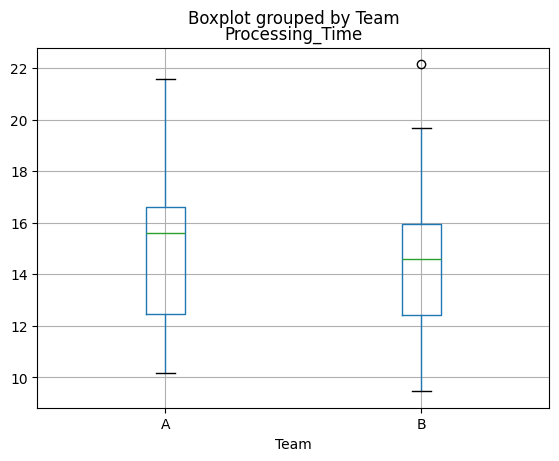

In [7]:
df.boxplot(by ='Team', column =['Processing_Time'])  # Box-plot

# Normality test using Shapiro test

In [8]:
Shapiro1 = stats.shapiro(df.Processing_Time[df.Team == 'A'])
print("Shapiro-Wilk test for Team A:", Shapiro1)

Shapiro-Wilk test for Team A: ShapiroResult(statistic=np.float64(0.9624749119809372), pvalue=np.float64(0.20335728105201517))


In [9]:
Shapiro2 = stats.shapiro(df.Processing_Time[df.Team == 'B'])
print("Shapiro-Wilk test for Team B:", Shapiro2)

Shapiro-Wilk test for Team B: ShapiroResult(statistic=np.float64(0.9708904417085259), pvalue=np.float64(0.38388917996153693))


# Normality check using Q-Q plot

In [10]:
from statsmodels.graphics.gofplots import qqplot
from matplotlib import pyplot

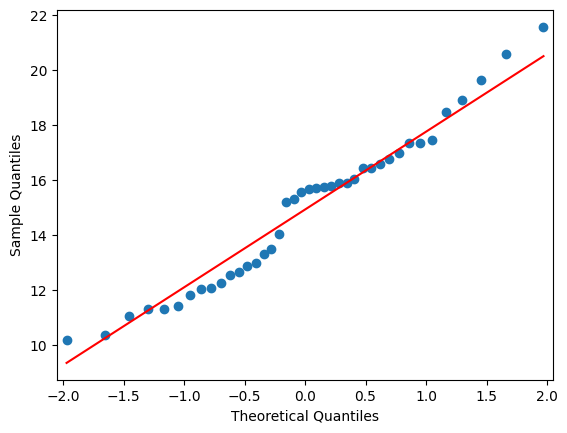

In [11]:
qqplot(df[df['Team'] == 'A']['Processing_Time'], line='s')
plt.show()

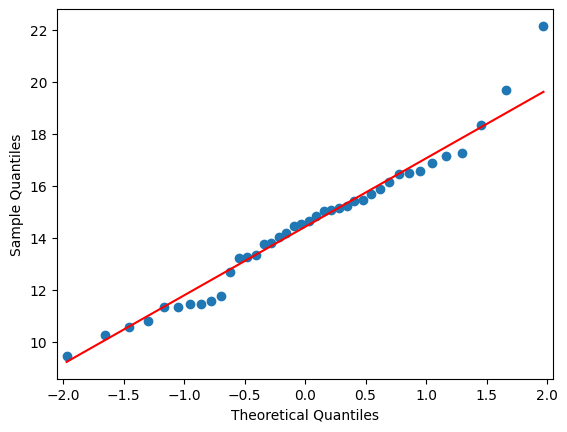

In [12]:
qqplot(df[df['Team'] == 'B']['Processing_Time'], line='s')
plt.show()


## Testing Equality of Variances

In [13]:
# Levene test using Center as Mean
stats.levene(df.Processing_Time[df.Team == 'A'],df.Processing_Time[df.Team == 'B'],center='mean')

LeveneResult(statistic=np.float64(0.8919041132805445), pvalue=np.float64(0.3478780966401447))

# Independent t test

In [14]:
res = stats.ttest_ind(df.Processing_Time[df.Team == 'A'],df.Processing_Time[df.Team == 'B'],equal_var=True,
  alternative='two-sided')
res

TtestResult(statistic=np.float64(0.8121172197724381), pvalue=np.float64(0.41919599218669157), df=np.float64(78.0))

In [15]:
print("Average performance of Class A:",(df.Processing_Time[df.Team == 'A']).mean())
print("Average performance of Class B:",(df.Processing_Time[df.Team == 'B']).mean())

Average performance of Class A: 14.921380021635155
Average performance of Class B: 14.417539804402548
